In [17]:
import numpy as np
# On recrée l'alias manuellement pour tromper la bibliothèque
np.NaN = np.nan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neuralprophet
from neuralprophet import NeuralProphet,set_log_level
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [18]:
#DESACTIVATION DES MESSAGES DE LOGS
set_log_level('ERROR')

In [19]:
import yfinance as yf

ticker = "GOOGL"
data = yf.download(ticker, start="2015-01-01", end="2025-12-31")

# On supprime le niveau supérieur (le nom du ticker)
data.columns = data.columns.droplevel(1) 

# 1. Supprimer le nom du groupe de colonnes "Price"
data.columns.name = None

# 2. Transformer la Date de "Index" à "Colonne normale"
data = data.reset_index()

print(data.head())

[*********************100%***********************]  1 of 1 completed

        Date      Close       High        Low       Open    Volume
0 2015-01-02  26.278944  26.589101  26.196068  26.430299  26480000
1 2015-01-05  25.778227  26.201529  25.693369  26.159844  41182000
2 2015-01-06  25.142036  25.865072  25.087945  25.829839  54456000
3 2015-01-07  25.068092  25.382715  24.993656  25.355919  46918000
4 2015-01-08  25.155430  25.184708  24.565387  24.887454  73054000


<Axes: xlabel='Date', ylabel='Close'>

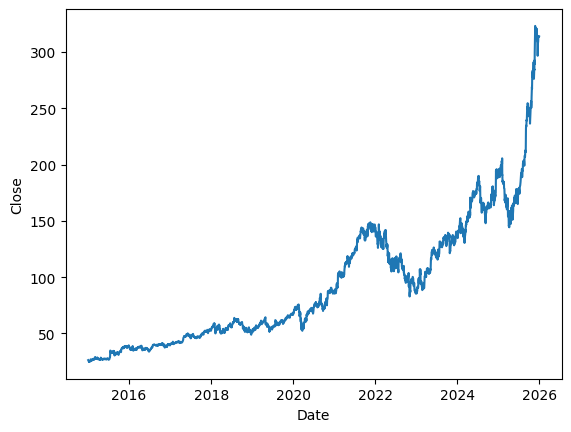

In [20]:
import seaborn as sns
sns.lineplot(x='Date',y='Close',data=data)

In [21]:
data.shape

(2765, 6)

In [22]:
#renommer les colonnes
data = data[['Date','Close']].rename(columns={'Date':'ds','Close':'y'})
data['ds'] = pd.to_datetime(data.ds)
data.dtypes

ds    datetime64[ns]
y            float64
dtype: object

In [23]:
# Configuration de Neural Prophet
model = NeuralProphet(
    n_lags=60, #n_lags c'est le forback
    n_forecasts=1,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    batch_size=32,
    epochs=300,
    learning_rate=0.001,
)

# Ajouter les jours féries (car ils augments le volume d'action échangés)
model.add_country_holidays(country_name='US')



In [24]:
# split train et test
df_train,df_test = model.split_df(data,freq='D',valid_p=0.2)
print("----------DEBUT D'ENTRAINEMENT-----------")
metrics = model.fit(df_train, validation_df=df_test, freq='D')
print("----------FIN D'ENTRAINEMENT-----------")

WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnin

----------DEBUT D'ENTRAINEMENT-----------
Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.




Training: |          | 0/? [13:30<?, ?it/s, v_num=3, MAE_val=2.700, RMSE_val=3.740, Loss_val=0.00184, RegLoss_val=0.000, train_loss=0.000307, reg_loss=0.000, MAE=1.040, RMSE=1.560, Loss=0.000307, RegLoss=0.000]
----------FIN D'ENTRAINEMENT-----------


In [43]:
# ============================================
# PRÉDICTION RÉCURSIVE (30 JOURS)
# ============================================

# Copie des données pour ne pas modifier l'original
data_extended = data.copy()

predictions_list = []
last_date = data['ds'].max()

print("=== PRÉDICTION RÉCURSIVE ===")

for i in range(30):
    # Créer le dataframe futur pour 1 jour
    future_one_day = model.make_future_dataframe(
        df=data_extended,
        periods=1,
        n_historic_predictions=False
    )
    
    # Prédire
    forecast_one = model.predict(future_one_day)
    
    # Extraire la prédiction du jour suivant
    next_pred = forecast_one.iloc[-1]
    next_date = next_pred['ds']
    next_value = next_pred['yhat1']
    
    print(f"Jour {i+1}: {next_date.date()} -> {next_value:.2f}")
    
    # Sauvegarder la prédiction
    predictions_list.append({
        'ds': next_date,
        'y': next_value,  # Utiliser la prédiction comme "vraie" valeur
        'yhat': next_value
    })
    
    # IMPORTANT : Ajouter cette prédiction aux données pour la prochaine itération
    new_row = pd.DataFrame({
        'ds': [next_date],
        'y': [next_value]  # Utiliser la prédiction comme nouvelle donnée
    })
    
    data_extended = pd.concat([data_extended, new_row], ignore_index=True)

# Créer un DataFrame avec toutes les prédictions
predictions_df = pd.DataFrame(predictions_list)

print("\n=== RÉSUMÉ DES 30 PRÉDICTIONS ===")
print(predictions_df[['ds', 'yhat']])

# Sauvegarder
predictions_df.to_csv('predictions_recursives_30j.csv', index=False)
print("\n✅ Prédictions sauvegardées!")

WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprec

=== PRÉDICTION RÉCURSIVE ===


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: FutureWarning:

`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.




Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 57.97it/s]

WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprec

...


Jour 28: 2026-01-27 -> 302.04


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


WARNING - (py.warnin

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 68.11it/s] 
Jour 29: 2026-01-28 -> 303.30


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning:

Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprec

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 66.36it/s]
Jour 30: 2026-01-29 -> 301.55

=== RÉSUMÉ DES 30 PRÉDICTIONS ===
           ds        yhat
0  2025-12-31  309.932098
1  2026-01-01  316.567017
2  2026-01-02  314.815125
3  2026-01-03  313.241577
4  2026-01-04  315.421906
5  2026-01-05  312.977020
6  2026-01-06  314.069092
7  2026-01-07  318.045349
8  2026-01-08  311.121155
9  2026-01-09  311.589264
10 2026-01-10  312.324432
11 2026-01-11  309.907379
12 2026-01-12  313.268524
13 2026-01-13  312.324646
14 2026-01-14  313.021149
15 2026-01-15  309.243988
16 2026-01-16  310.620697
17 2026-01-17  311.413055
18 2026-01-18  312.070648
19 2026-01-19  310.625031
20 2026-01-20  310.561401
21 2026-01-21  305.357361
22 2026-01-22  306.292847
23 2026-01-23  307.784912
24 2026-01-24  303.070648
25 2026-01-25  306.342865
26 2026-01-26  302.895355
27 2026-01-27  302.040314
28 2026-01-28  303.299438
29 2026-01-29  301.546478

✅ Prédictions sauvegardées!


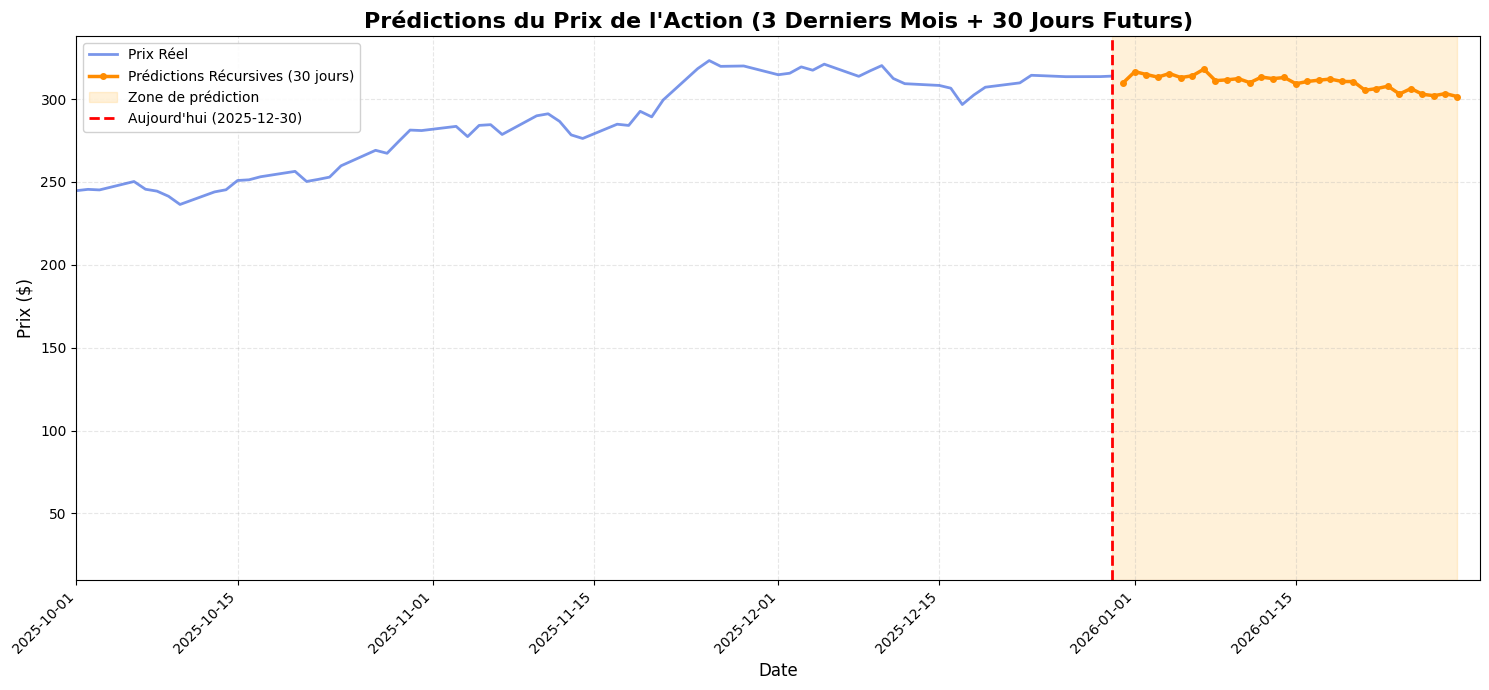

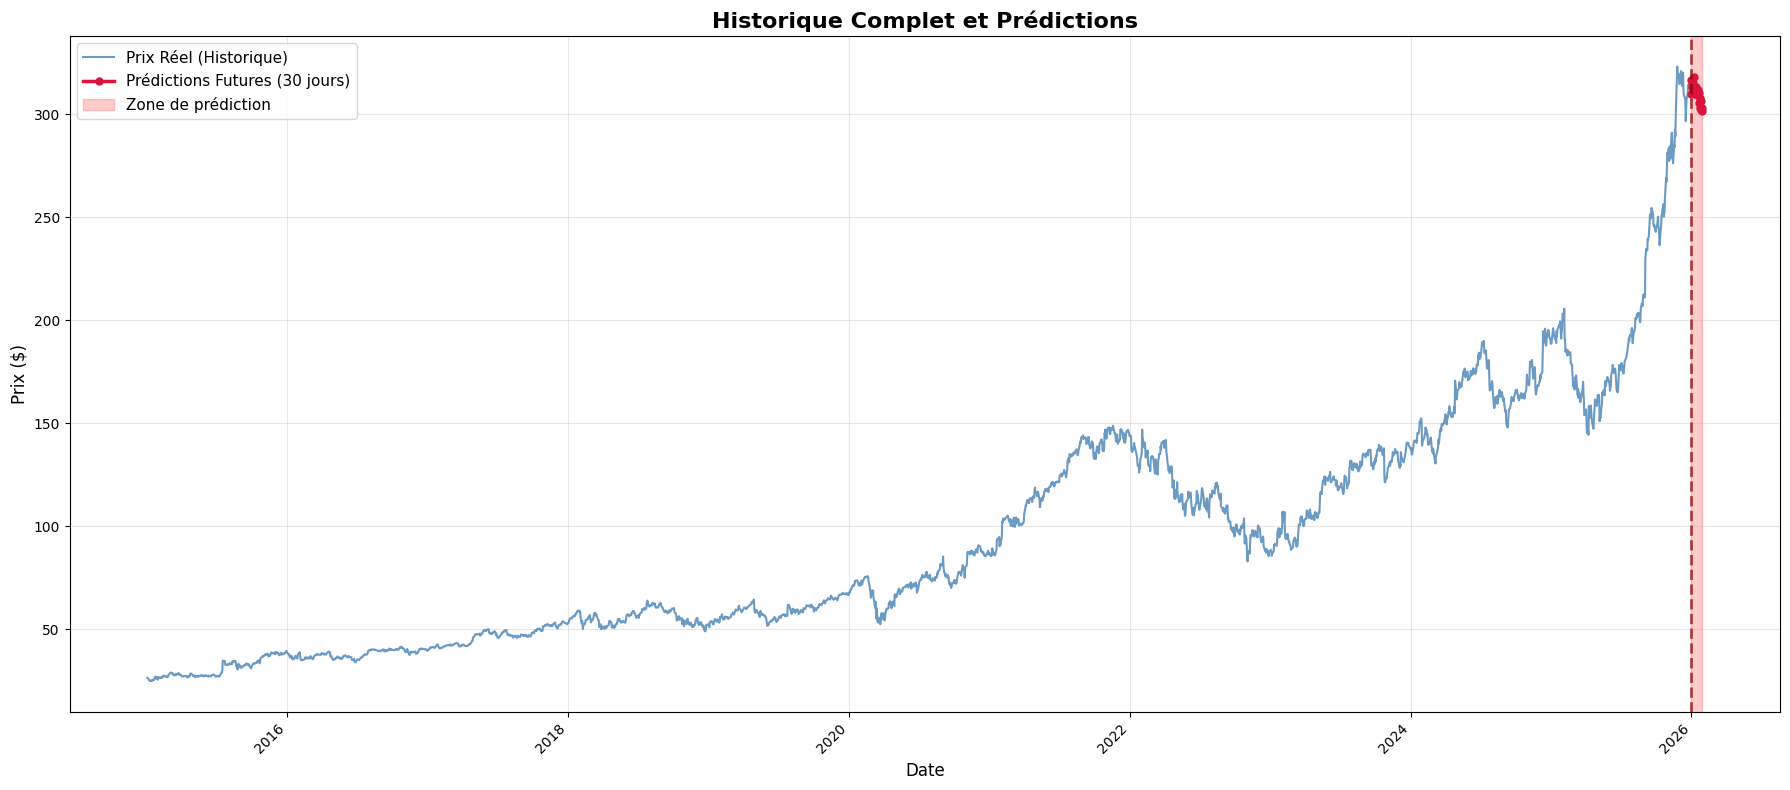

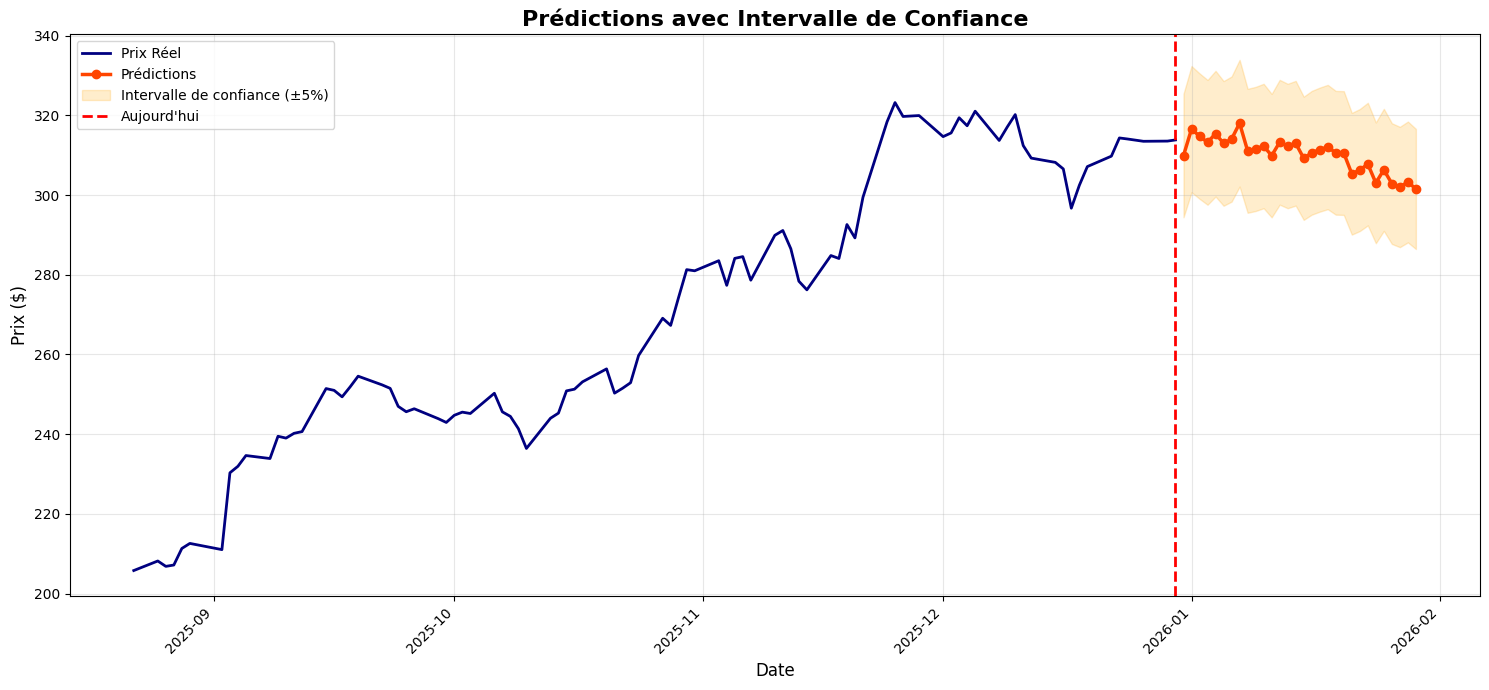


STATISTIQUES DES PRÉDICTIONS

📊 Prix actuel (dernier jour réel): $313.85
🔮 Prix prédit dans 30 jours: $301.55
📈 Variation attendue: $-12.30 (-3.92%)
⚠️ Tendance: BAISSIÈRE (baisse attendue)

📉 Prix minimum prédit: $301.55
📈 Prix maximum prédit: $318.05
📊 Prix moyen prédit: $310.06
📊 Volatilité prédite: $4.43



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# GRAPHIQUE DES PRÉDICTIONS RÉCURSIVES: le jour predit sert de valeur pour le jour suivant

# Déterminer la dernière date réelle
last_real_date = data['ds'].max()

# Créer la figure
plt.figure(figsize=(15, 7))

# 1. Tracer les données réelles (historiques)
plt.plot(data['ds'], data['y'], 
         label='Prix Réel', 
         color='royalblue', 
         linewidth=2, 
         alpha=0.7)

# 2. Tracer les prédictions récursives (30 jours futurs)
plt.plot(predictions_df['ds'], predictions_df['yhat'], 
         label='Prédictions Récursives (30 jours)', 
         color='darkorange', 
         linewidth=2.5, 
         marker='o', 
         markersize=4)

# 3. Ajouter une zone ombrée pour les prédictions
plt.axvspan(last_real_date, predictions_df['ds'].max(), 
            alpha=0.15, 
            color='orange', 
            label='Zone de prédiction')

# 4. Ligne verticale pour marquer la séparation
plt.axvline(x=last_real_date, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label=f'Aujourd\'hui ({last_real_date.date()})')

# 5. Zoom sur les 3 derniers mois + 30 jours de prédiction
date_debut_zoom = last_real_date - pd.Timedelta(days=90)
date_fin_zoom = predictions_df['ds'].max() + pd.Timedelta(days=2)

plt.xlim(date_debut_zoom, date_fin_zoom)

# 6. Mise en forme
plt.title("Prédictions du Prix de l'Action (3 Derniers Mois + 30 Jours Futurs)", 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='best', fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Afficher
plt.show()

# GRAPHIQUE COMPLET (TOUTES LES DONNÉES)

plt.figure(figsize=(18, 8))

# Tracer toutes les données réelles
plt.plot(data['ds'], data['y'], 
         label='Prix Réel (Historique)', 
         color='steelblue', 
         linewidth=1.5, 
         alpha=0.8)

# Tracer les prédictions
plt.plot(predictions_df['ds'], predictions_df['yhat'], 
         label='Prédictions Futures (30 jours)', 
         color='crimson', 
         linewidth=2.5, 
         marker='o', 
         markersize=5)

# Zone de prédiction
plt.axvspan(last_real_date, predictions_df['ds'].max(), 
            alpha=0.2, 
            color='red', 
            label='Zone de prédiction')

# Ligne de séparation
plt.axvline(x=last_real_date, 
            color='darkred', 
            linestyle='--', 
            linewidth=2, 
            alpha=0.7)

# Mise en forme
plt.title("Historique Complet et Prédictions", 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# GRAPHIQUE AVEC INTERVALLES DE CONFIANCE

# Si vous voulez ajouter une bande d'incertitude autour des prédictions
plt.figure(figsize=(15, 7))

# Données réelles
plt.plot(data['ds'].tail(90), data['y'].tail(90), 
         label='Prix Réel', 
         color='navy', 
         linewidth=2)

# Prédictions
plt.plot(predictions_df['ds'], predictions_df['yhat'], 
         label='Prédictions', 
         color='orangered', 
         linewidth=2.5, 
         marker='o')

# Intervalle de confiance simulé (±5% autour de la prédiction)
lower_bound = predictions_df['yhat'] * 0.95
upper_bound = predictions_df['yhat'] * 1.05

plt.fill_between(predictions_df['ds'], 
                 lower_bound, 
                 upper_bound, 
                 color='orange', 
                 alpha=0.2, 
                 label='Intervalle de confiance (±5%)')

# Ligne de séparation
plt.axvline(x=last_real_date, 
            color='red', 
            linestyle='--', 
            linewidth=2, 
            label='Aujourd\'hui')

# Mise en forme
plt.title("Prédictions avec Intervalle de Confiance", 
          fontsize=16, 
          fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# STATISTIQUES DES PRÉDICTIONS

print("\n" + "="*60)
print("STATISTIQUES DES PRÉDICTIONS")
print("="*60)

# Valeur de départ et d'arrivée
prix_actuel = data['y'].iloc[-1]
prix_predit_30j = predictions_df['yhat'].iloc[-1]

# Variation
variation = prix_predit_30j - prix_actuel
variation_pct = (variation / prix_actuel) * 100

print(f"\n📊 Prix actuel (dernier jour réel): ${prix_actuel:.2f}")
print(f"🔮 Prix prédit dans 30 jours: ${prix_predit_30j:.2f}")
print(f"📈 Variation attendue: ${variation:.2f} ({variation_pct:+.2f}%)")

# Tendance
if variation_pct > 2:
    print("✅ Tendance: HAUSSIÈRE (forte hausse attendue)")
elif variation_pct > 0:
    print("📊 Tendance: Légèrement haussière")
elif variation_pct > -2:
    print("➡️ Tendance: Stable")
else:
    print("⚠️ Tendance: BAISSIÈRE (baisse attendue)")

# Min/Max des prédictions
print(f"\n📉 Prix minimum prédit: ${predictions_df['yhat'].min():.2f}")
print(f"📈 Prix maximum prédit: ${predictions_df['yhat'].max():.2f}")
print(f"📊 Prix moyen prédit: ${predictions_df['yhat'].mean():.2f}")
print(f"📊 Volatilité prédite: ${predictions_df['yhat'].std():.2f}")

print("\n" + "="*60)

In [44]:
# Afficher les dernières lignes de vos données originales
print("Dernières dates dans les données d'entraînement:")
print(data['ds'].tail(10))
print(f"\nDernière date : {data['ds'].max()}")

Dernières dates dans les données d'entraînement:
2755   2025-12-16
2756   2025-12-17
2757   2025-12-18
2758   2025-12-19
2759   2025-12-22
2760   2025-12-23
2761   2025-12-24
2762   2025-12-26
2763   2025-12-29
2764   2025-12-30
Name: ds, dtype: datetime64[ns]

Dernière date : 2025-12-30 00:00:00


In [50]:
plot1 = model.plot(forecast)
plot1

ERROR - (NP.plotly.plot) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




In [51]:
plt2 = model.plot_components(forecast)
plt2

ERROR - (NP.plotly.plot_components) - plotly-resampler is not installed. Please install it to use the resampler.
WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\plot_forecast_plotly.py:410: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result


WARNING - (py.warnings._showwarnmsg) - e:\M2_s1\all_environements\torch\lib\site-packages\neuralprophet\plot_forecast_plotly.py:559: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result




In [52]:
# enregistrer le modèle
torch.save(model, "neural_prophet_model.pt")
print("Modèle exporté avec succès sous 'neural_prophet_model.pt'")

Modèle exporté avec succès sous 'neural_prophet_model.pt'
